### BTO API tutorial

**Purpose.** Learn each component of the BTO analysis API interface: inspect the detector
library and its directional dependence, query one source/detector response,
apply resolution/gain/threshold, write/read OGIP, add background and simulate a
reproducible measured spectrum. This notebook demonstrates BTO1 and shows BTO1/BT.

The input CC background is **albedo photons**, as explicitly described by
COSIpy's GRB tutorial. It is not a total satellite background: cosmic diffuse
photons, charged particles, neutrons and activation/SAA components must not be
assumed to be present. The local file matches the tutorial's download checksum.
Its `PsiChi` metadata is `spacecraftframe`, the local coordinate system used by
the installed response interface. In contrast, the BTO reference mean is built
from 11 simulated components. This example teaches response-consistent joint
fitting; it is not a full-background mission sensitivity forecast.

**Inputs (Section 1).** Use the installed `cosipy` environment and keep the
project directory with its response/ and api/ subdirectories available; run all cells in order.

| Variable | Meaning |
|---|---|
| `response_h5_path` | `bto_response_order2.h5`, format `COSI-BTO-unsmeared-response`: BTO1/BTO2 Geant4 effective-area matrices versus direction, true energy and deposited energy. **No Gaussian resolution, gain, measured-energy threshold or saturation is applied in this HDF5.** It is the reusable all-direction input, not a ready-to-fit recorded-channel response. |
| `orientation_path` | COSIpy's simulated attitude/livetime FITS for constructing a celestial-source response over a time interval. Fixed spacecraft-direction queries do not need it. |
| `background_template_path` | `BTO_background_template_10-3000keV.fits`: single-BTO mean background rebuilt from eleven weighted simulation components over 10--3000 keV. The file stores its own `EBOUNDS`, `RATE`, weighted/smoothed expected `COUNTS`, reference exposure and component provenance. The API reads these boundaries and regrids the mean to the requested response; no native-grid constants or external RMF are required. |

`bto_api_path` locates the module; `output_path` receives generated products.
There is no CC response/background dependency here. All scientific settings are
visible in the cells; none are inferred from a YAML file or an earlier fit result.

**Workflow and response levels.**

1. **Sections 1--2:** set paths/style and inspect HDF5 labels, dimensions and units.
   Section 2b computes an interpolated BTO1/BTO2 area map near 1 MeV from the HDF5,
   showing the spacecraft direction convention and passive-material attenuation.
2. **Section 3:** explicitly choose quadratic gain, channel count, threshold,
   saturation and resolution. These adjustable presets are not flight calibration.
3. **Section 4:** call `get_bto_response` for a Galactic source and ON interval.
   It interpolates directions, averages with the history and converts deposited
   energy to measured-channel probability using integrated Gaussian edges.
4. **Section 5:** compare all-deposit Geant4 area, full-energy proxy and recorded
   area; view the deposit matrix. The proxy is not a selection of Geant4
   photoelectric process labels. Fake generation/fitting uses the full recorded
   RSP, including partial-energy redistribution.
5. **Section 6:** use `write_ogip_response` to write recorded ARF/RMF/RSP, then
   `load_bto_response` to demonstrate reusing that resolution-applied product.
   **Do not apply resolution again when loading OGIP.** Existing generated RSPs
   are specific to their source/time/calibration; the all-direction HDF5 remains
   unsmeared so a different calibration can be applied without double convolution.
6. **Section 7:** `get_bto_background` regrids the constant reference rate;
   `write_ogip_background` makes its BAK on the new detector grid.
7. **Section 8:** define a Band model, integrate and fold it through RSP, add
   background and draw seeded Poisson counts with `simulate_bto_spectrum`.
   Show a step histogram with error bars and write the fake PHA.
8. **Section 9:** load PHA/response/background with standard threeML `OGIPLike`
   (a loading demonstration, not a CC or joint fit).

The six named public functions above are the component API; `_` names are
internal helpers. Arrays and metadata remain in `response`, `background` and
`fake`. Input files stay read-only. OGIP response/background/PHA, metadata and
quick-look figures are written below `output_path` and plots are displayed inline.

#### 1. Imports and explicit paths

The HDF5 is the unsmeared response library; the history supplies the source's
changing spacecraft direction. The self-contained FITS template supplies a mean background spectrum
and its own energy edges; no background RMF is required. Generated response/background/PHA and figures go to `output_path`.

In [1]:
from pathlib import Path
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astromodels import Band
from threeML.plugins.OGIPLike import OGIPLike

# Change only this root if you move the complete project directory.
project_path = Path('/Users/shunsaku/work/COSI/sim_solar_cosipy/tutorial_grb_fit_with_bto_response')
response_path = project_path / 'response'
bto_api_path = project_path / 'api'
response_h5_path = response_path / 'bto_response_order2.h5'
orientation_path = response_path / '20280301_3_month_with_orbital_info.fits'
background_template_path = response_path / 'BTO_background_template_10-3000keV.fits'
output_path = project_path / 'notebook_output' / 'bto_api'
output_path.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(bto_api_path))

from bto_response import (
    BTOCalibration, Prototype_Resolution,
    get_bto_response, write_ogip_response, load_bto_response,
    get_bto_background, write_ogip_background, simulate_bto_spectrum,
)

STYLE = {
    "font.family": "Times New Roman", "mathtext.fontset": "stix",
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 1.5, "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0, "ytick.minor.width": 1.0,
    "xtick.major.size": 10, "ytick.major.size": 10,
    "xtick.minor.size": 5, "ytick.minor.size": 5,
    "xtick.top": True, "ytick.right": True,
    "savefig.facecolor": "white", "font.size": 14,
    "axes.linewidth": 1.5, "legend.fancybox": False,
    "axes.spines.top": True, "axes.spines.right": True,
}
plt.rcParams.update(STYLE)
plt.rcParams.update({'axes.titlesize': 14, 'figure.titlesize': 14})
def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(1.5)
    ax.tick_params(which='both', direction='in', top=True, right=True)
print('Output:', output_path)

16:49:20 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=6431594;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=6431595;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=6431603;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=6431604;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=6431613;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=6431614;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

16:49:20 INFO      Starting 3ML!                                                                     ]8;id=6431623;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6431624;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

WARNING   WARNINGs here are NOT errors                                                      ]8;id=6431632;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6431633;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

WARNING   No fermitools installed                                              ]8;id=6431697;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=6431698;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=6431706;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6431707;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=6431714;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6431715;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=6431722;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6431723;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

Output: /Users/shunsaku/work/COSI/sim_solar_cosipy/tutorial_grb_fit_with_bto_response/notebook_output/bto_api


#### 2. Inspect the input HDF5 schema

The core array is `response/area_matrix_cm2[detector, direction, Etrue, Edeposit]`. Detector names are read from `detector/name`, so BTO1 and BTO2 are never selected by an assumed index. `response/arf_cm2` is the deposit-axis sum before electronics effects.

In [2]:
with h5py.File(response_h5_path, 'r') as h5:
    print('format:', h5.attrs['format'], 'schema:', h5.attrs['schema_version'])
    print('detectors:', [x.decode() if isinstance(x, bytes) else str(x) for x in h5['detector/name'][...]])
    for name in ('direction/vector', 'energy/true_edges_keV', 'energy/deposit_edges_keV',
                 'response/area_matrix_cm2', 'response/arf_cm2'):
        print(f'{name:34s}', h5[name].shape)
    print('direction scheme:', h5.attrs['direction_scheme'], 'nside:', h5.attrs['healpix_nside'])

format: COSI-BTO-unsmeared-response schema: 1
detectors: ['BTO1', 'BTO2']
direction/vector                   (192, 3)
energy/true_edges_keV              (101,)
energy/deposit_edges_keV           (1051,)
response/area_matrix_cm2           (2, 192, 100, 1050)
response/arf_cm2                   (2, 192, 100)
direction scheme: HEALPix RING nside: 4


#### 2b. Mollweide all-sky quick look and the GRB direction

This is a sky-map-style **Mollweide projection in spacecraft coordinates**, not
a map in Galactic longitude/latitude. Azimuth $\phi=0$ points to +X and increases
to the left; the vertical angle is elevation $90^\circ-\theta$, so +Z is at the top.
Photon propagation is opposite to the source line of sight. The projection is
equal-area; its elliptical border is the complete sky.

At the selected true-energy bin, colors show all-deposit effective area before
detector effects, interpolated on the sphere from the nearest four simulated
directions. Both BTO panels share a rainbow color scale. Small circles show the
192 simulation centers; interpolation does not add new angular statistics.

The **white star** is the GRB's livetime-weighted mean spacecraft direction over
the same 40 s interval used for the fit. A white track shows its attitude-driven
motion. It is calculated from Galactic (93,-53) using `SpacecraftHistory`, not
plotted directly at those Galactic angles. Earth occultation is disabled here,
as in the GRB example. The recorded ARF used for fitting is built in Section 4.

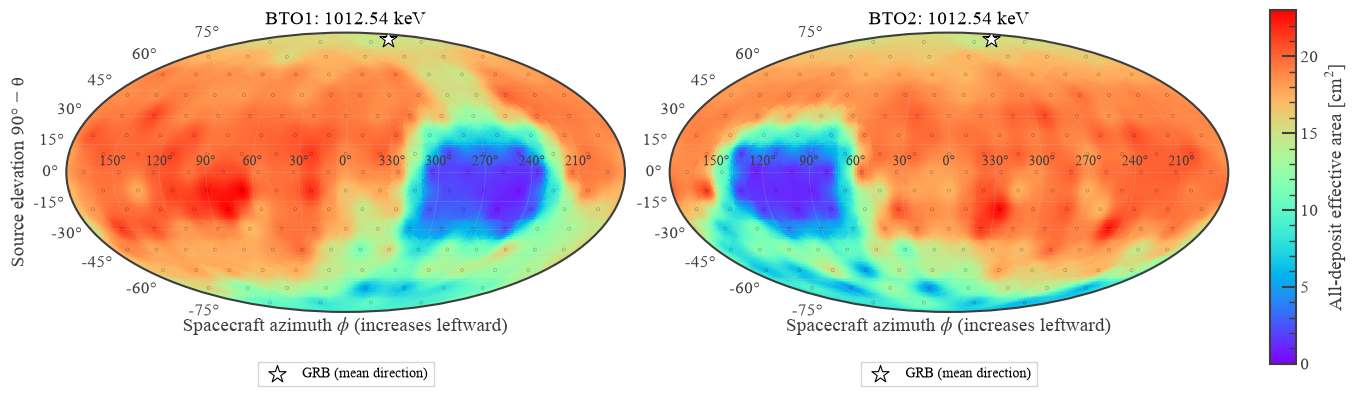

GRB mean spacecraft azimuth = 270.873 deg; elevation = 81.031 deg
Template-independent unsmeared area at 1012.5351429936728 keV


In [3]:
map_energy_keV = 1000.0
source_coord = SkyCoord(l=93.0*u.deg, b=-53.0*u.deg, frame='galactic')
tstart = Time('2028-05-22T08:36:50')
tstop = tstart + 40.0*u.s

with h5py.File(response_h5_path, 'r') as h5:
    detector_names = [x.decode() if isinstance(x, bytes) else str(x) for x in h5['detector/name'][...]]
    true_centers = h5['energy/true_centers_keV'][...]
    energy_index = int(np.argmin(np.abs(true_centers-map_energy_keV)))
    map_energy_actual = float(true_centers[energy_index])
    center_vectors = h5['direction/vector'][...]
    center_vectors /= np.linalg.norm(center_vectors, axis=1)[:, None]
    center_theta = h5['direction/theta_deg'][...]
    center_phi = h5['direction/phi_deg'][...]
    center_area = h5['response/arf_cm2'][:, :, energy_index]

# Plot longitude increases to the right, but spacecraft azimuth increases leftward.
plot_lon = np.linspace(-np.pi, np.pi, 361)
elevation = np.linspace(-np.pi/2, np.pi/2, 181)
lon_mesh, lat_mesh = np.meshgrid(plot_lon, elevation)
phi_mesh = -lon_mesh
query_vectors = np.column_stack((np.cos(lat_mesh.ravel())*np.cos(phi_mesh.ravel()),
                                np.cos(lat_mesh.ravel())*np.sin(phi_mesh.ravel()),
                                np.sin(lat_mesh.ravel())))
query_vectors[np.abs(query_vectors) < 1e-15] = 0.0
query_vectors /= np.linalg.norm(query_vectors, axis=1)[:, None]
angular_distance = np.arccos(np.clip(query_vectors @ center_vectors.T, -1., 1.))
neighbor = np.argsort(angular_distance, axis=1)[:, :4]
distance = np.take_along_axis(angular_distance, neighbor, axis=1)
weights = 1.0/np.maximum(distance, 1e-12)**2
weights /= weights.sum(axis=1, keepdims=True)
weights[distance[:, 0] < 1e-10] = [1., 0., 0., 0.]
maps = {name: np.sum(center_area[detector_names.index(name)][neighbor]*weights, axis=1).reshape(lat_mesh.shape)
        for name in ('BTO1', 'BTO2')}
for values in maps.values():
    assert np.all(np.isfinite(values)) and np.all(values >= 0.)
    np.testing.assert_allclose(values[:, 0], values[:, -1], atol=1e-6)

# Use the same installed COSIpy transformation and time/livetime weighting as the API.
from cosipy.spacecraftfile import SpacecraftHistory
map_history = SpacecraftHistory.open(orientation_path, tstart=tstart, tstop=tstop).select_interval(tstart, tstop)
local_grb = map_history.get_target_in_sc_frame(source_coord)
grb_phi = np.asarray(local_grb.lon.to_value(u.rad))
grb_lat = np.asarray(local_grb.lat.to_value(u.rad))
grb_vectors = np.column_stack((np.cos(grb_lat)*np.cos(grb_phi),
                               np.cos(grb_lat)*np.sin(grb_phi), np.sin(grb_lat)))
dt = np.diff(map_history.obstime.unix)
interval_weight = np.asarray(map_history.get_source_visibility(None).to_value(u.s))
interval_weight = np.where(dt > 0, interval_weight, 0.)
point_weight = np.zeros(len(grb_phi))
point_weight[:-1] += interval_weight/2
point_weight[1:] += interval_weight/2
assert point_weight.sum() > 0
mean_vector = np.average(grb_vectors, axis=0, weights=point_weight)
mean_vector /= np.linalg.norm(mean_vector)
mean_phi = np.arctan2(mean_vector[1], mean_vector[0])
mean_lat = np.arcsin(np.clip(mean_vector[2], -1., 1.))
grb_plot_lon = (-(grb_phi+np.pi) % (2*np.pi))-np.pi
# Break a path across the projection seam rather than drawing across the whole sky.
track_lon = grb_plot_lon.copy()
track_lon[np.r_[False, np.abs(np.diff(track_lon)) > np.pi]] = np.nan
vmax = max(values.max() for values in maps.values())
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), subplot_kw={'projection':'mollweide'})
for ax, name in zip(axes, ('BTO1','BTO2')):
    mesh = ax.pcolormesh(lon_mesh, lat_mesh, maps[name], cmap='rainbow',
                         vmin=0., vmax=vmax, shading='auto', rasterized=True)
    center_lon = (-(np.deg2rad(center_phi)+np.pi) % (2*np.pi))-np.pi
    ax.scatter(center_lon, np.deg2rad(90.-center_theta), s=5,
               facecolors='none', edgecolors='black', linewidths=0.3, alpha=0.4)
    ax.plot(track_lon, grb_lat, color='white', lw=1.5)
    ax.scatter([-mean_phi], [mean_lat], marker='*', s=170, facecolor='white',
               edgecolor='black', linewidth=0.8, zorder=5, label='GRB (mean direction)')
    ticks = np.deg2rad(np.arange(-150, 180, 30))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{(-int(x))%360}°' for x in np.arange(-150,180,30)], fontsize=10)
    ax.set_xlabel(r'Spacecraft azimuth $\phi$ (increases leftward)')
    ax.set_title(f'{name}: {map_energy_actual:.2f} keV', fontsize=14)
    ax.grid(alpha=0.25)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(1.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,-0.29), fontsize=10, frameon=True)
axes[0].set_ylabel('Source elevation 90° − θ')
fig.subplots_adjust(left=0.06, right=0.89, bottom=0.23, top=0.91, wspace=0.08)
cax = fig.add_axes([0.92,0.24,0.018,0.61])
fig.colorbar(mesh, cax=cax, label=r'All-deposit effective area [cm$^2$]')
fig.savefig(output_path/'bto1_bto2_arf_skymap_interpolated.png', dpi=180)
plt.show()
print(f'GRB mean spacecraft azimuth = {np.rad2deg(mean_phi)%360:.3f} deg; elevation = {np.rad2deg(mean_lat):.3f} deg')
print('Template-independent unsmeared area at', map_energy_actual, 'keV')

#### 3. Choose detector calibration and resolution

Gain uses `channel = a E^2 + b E + c`. The example below includes a small quadratic term only to demonstrate the interface; it is **not flight calibration**. The default resolution is likewise a prototype-normalized approximation with FWHM(662 keV) = 65 keV, not the unpublished full fit and not a flight value.

In [4]:
calibration = BTOCalibration(
    n_channels=4096,
    gain_quadratic_ch_per_keV2=1.0e-5,  # tutorial placeholder
    gain_slope_ch_per_keV=1.0/0.8125,
    gain_offset_ch=0.0,
    lower_threshold_keV=30.0,
    upper_saturation_keV=3000.0,
    name='quadratic tutorial placeholder',
    provenance='demonstration only; not flight calibration',
)
energy_edges = calibration.measured_energy_edges_keV
channel_from_edges = (calibration.gain_quadratic_ch_per_keV2*energy_edges**2
                      + calibration.gain_slope_ch_per_keV*energy_edges
                      + calibration.gain_offset_ch)
print('energy range [keV]:', energy_edges[[0, -1]])
print('maximum round-trip channel error:', np.max(np.abs(channel_from_edges-calibration.channel_edges)))

energy range [keV]: [   0.         3242.57155395]
maximum round-trip channel error: 9.094947017729282e-13


#### 4. Build one orientation-averaged BTO1 response

Required inputs are the HDF5 path and BTO ID. This celestial mode additionally requires orientation file, source coordinate, start, and stop. The API transforms every sampled source direction to the spacecraft frame, applies the same four-neighbor spherical interpolation used for fixed directions, and livetime-weights the response.

In [5]:
source_coord = SkyCoord(l=93.0*u.deg, b=-53.0*u.deg, frame='galactic')
tstart = Time('2028-05-22T08:36:50')
tstop = tstart + 40.0*u.s
response = get_bto_response(
    response_h5_path, 'BTO1',
    orientation_file=orientation_path, source_coord=source_coord,
    tstart=tstart, tstop=tstop, calibration=calibration,
    resolution=Prototype_Resolution,
    earth_occultation=False, write_ogip=False,
)
print(response.detector_name, response.rsp_cm2.shape)
print('orientation samples:', response.metadata['orientation_samples'])
print('max |sum(A_dep)-ARF_unsmeared|:',
      np.max(np.abs(response.unsmeared_area_matrix_cm2.sum(axis=1)-response.unsmeared_arf_cm2)))

BTO1 (100, 4096)
orientation samples: 42
max |sum(A_dep)-ARF_unsmeared|: 0.0


#### 5. Understand the effective areas and the deposit matrix

The three curves answer different questions. Let
$A_{ik}$ be `unsmeared_area_matrix_cm2[true-energy i, deposit-energy k]`,
already interpolated in direction and averaged over this observation.

| Array / curve | Definition | Interpretation and use |
| --- | --- | --- |
| `unsmeared_arf_cm2` (blue) | $\sum_k A_{ik}$ | Geant4 deposit acceptance: all stored deposits, including partial-energy Compton deposits and full-energy deposits, before the API's detector detector effects model. This diagnostic is limited to the deposit range and event selection of the input HDF5. |
| `photopeak_arf_cm2` (red) | Sum of $A_{ik}$ over deposit-bin **centers** inside true-energy bin $i$ | Approximate full-energy/photopeak acceptance. The finite-bin definition is a proxy, not an interaction-process selection: a photon can scatter then be fully absorbed. It is not a photoelectric-only response and is not the response used to fit this continuum. |
| `arf_cm2` (black) | $\sum_j R_{ij}$, where $R_{ij}=\sum_k A_{ik}P(j\mid k)$ | Recorded-event acceptance after the selected gain, energy-resolution and acquisition-limit model. This is the ARF written to OGIP and used with the RMF in the fit. |

The **detector effects model** consists of the following simplified
detector detector effects model implemented in the BTO API:

1. Gain maps measured energy to channel, $c=aE_{\rm meas}^2+bE_{\rm meas}+c_0$.
2. A Gaussian energy-resolution kernel redistributes each deposit into measured
   channels; probabilities are integrated between channel edges with a Gaussian CDF.
3. Probability below the measured-energy threshold, above the saturation limit,
   or outside the channel range is lost from the recorded response.

It does not model the electronics waveform, pile-up, dead time, or trigger timing.
Smearing conserves area if all redistributed probability is accepted; losses
from threshold/saturation/channel limits reduce the black curve relative to blue.
For example, a 500 keV photon that deposits 100 keV contributes to blue and,
if recorded, to black and to the 100 keV part of the redistribution matrix. It
does not contribute to the 500 keV photopeak proxy in red.

**What this tutorial actually fits:** `simulate_bto_spectrum` folds the source
through `response.rsp_cm2`. `OGIPLike` loads `response.rmf_path` together with
`response.arf_path`. These are equivalent because

$$R_{ij}=\mathrm{arf\_cm2}[i]\,\mathrm{rmf\_probability}[i,j].$$

The RMF includes both partial-energy and full-energy events; its nonzero rows
sum to one conditional on recording the event. The diagnostic blue/red ARFs
are not substituted for the black ARF. The additional **30–2500 keV fit range**
selects measured channels in the likelihood after constructing the response.

The GRB notebooks currently use the API defaults: 4096 channels, linear gain
0.8125 keV/channel, zero offset, measured threshold 30 keV, saturation 3000 keV,
and constant fractional Gaussian FWHM/E = 65/662. These are configurable analysis
placeholders. Only the normalization of the resolution at 662 keV comes from
the prototype measurement; this is not a measured flight calibration.
The API-component notebook instead explicitly supplies its demonstration
quadratic gain. The next cell prints the actual calibration and resolution
objects used, so the plotted model can be checked without guessing from a label.

BTOCalibration(n_channels=4096, gain_quadratic_ch_per_keV2=1e-05, gain_slope_ch_per_keV=1.2307692307692308, gain_offset_ch=0.0, lower_threshold_keV=30.0, upper_saturation_keV=3000.0, name='quadratic tutorial placeholder', provenance='demonstration only; not flight calibration')
BTOResolution(a0_keV2=0.0, a1_keV=0.0, a2=0.0017385824300377962, name='Prototype resolution (approximate constant fraction)', provenance='Approximation normalized to the reported 65 keV FWHM at 662 keV; Nagasawa et al. 2025 prototype; not full-fit coefficients or flight calibration')


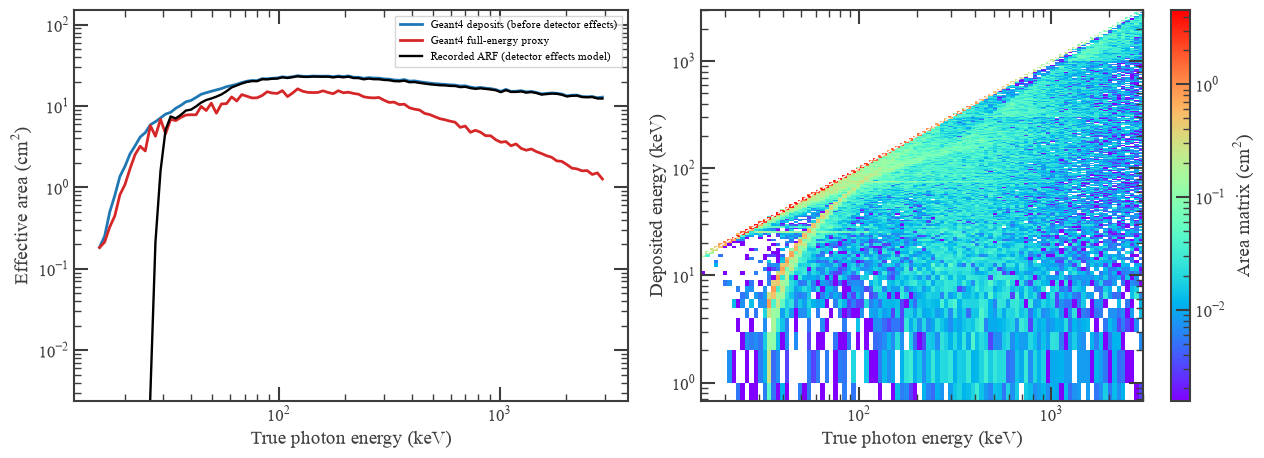

In [6]:
print(response.calibration, response.resolution, sep='\n')
etrue = np.sqrt(response.photon_energy_edges_keV[:-1]*response.photon_energy_edges_keV[1:])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
# Blue: sum over ALL stored deposit bins, before smearing or measured-energy cuts.
axes[0].plot(etrue, response.unsmeared_arf_cm2, color='tab:blue', lw=2, label='Geant4 deposits (before detector effects)')
axes[0].plot(etrue, response.photopeak_arf_cm2, color='tab:red', lw=2, label='Geant4 full-energy proxy')
axes[0].plot(etrue, response.arf_cm2, color='black', lw=1.7, label='Recorded ARF (detector effects model)')
displayed = np.concatenate((response.unsmeared_arf_cm2, response.photopeak_arf_cm2, response.arf_cm2))
display_floor = max(1.0e-4, 1.0e-4*np.nanmax(displayed))
axes[0].set(xscale='log', yscale='log', xlabel='True photon energy (keV)',
            ylabel=r'Effective area (cm$^2$)', ylim=(display_floor, None))
axes[0].legend(frameon=True)
positive = np.where(response.unsmeared_area_matrix_cm2 > 0, response.unsmeared_area_matrix_cm2, np.nan)
mesh = axes[1].pcolormesh(response.photon_energy_edges_keV, response.deposit_energy_edges_keV,
                          positive.T, norm=LogNorm(), cmap='rainbow', shading='auto')
axes[1].plot([15,3000],[15,3000], color='white', ls='--', lw=1)
axes[1].set(xscale='log', yscale='log', xlabel='True photon energy (keV)', ylabel='Deposited energy (keV)')
style_axes(axes[0]); style_axes(axes[1])
fig.colorbar(mesh, ax=axes[1], label=r'Area matrix (cm$^2$)')
fig.tight_layout(); fig.savefig(output_path/'bto_response_components.png', dpi=180); plt.show()

#### 6. Write and read OGIP response files

`write_ogip_response` writes a conditional RMF, its observed ARF, a combined RSP, and JSON metadata. `load_bto_response` is useful for later analyses that should not repeat HDF5 interpolation.

In [7]:
response_prefix = output_path / 'bto1_grb_l93_bm53'
write_ogip_response(response, response_prefix, overwrite=True)
reloaded = load_bto_response(response.rmf_path, arf_file=response.arf_path)
print(response.arf_path, response.rmf_path, response.rsp_path, sep='\n')
print('max ARF round-trip difference:', np.max(np.abs(reloaded.arf_cm2-response.arf_cm2)))

/Users/shunsaku/work/COSI/sim_solar_cosipy/tutorial_grb_fit_with_bto_response/notebook_output/bto_api/bto1_grb_l93_bm53.arf
/Users/shunsaku/work/COSI/sim_solar_cosipy/tutorial_grb_fit_with_bto_response/notebook_output/bto_api/bto1_grb_l93_bm53.rmf
/Users/shunsaku/work/COSI/sim_solar_cosipy/tutorial_grb_fit_with_bto_response/notebook_output/bto_api/bto1_grb_l93_bm53.rsp
max ARF round-trip difference: 9.240633360718675e-07


#### 7. Read the self-contained background template and regrid it

The template covers **10--3000 keV**, with its own `EBOUNDS`, `SPECTRUM`,
`COMPONENTS` and `PROVENANCE` tables. `RATE` is the mean counts/s in each bin;
`COUNTS = RATE * EXPOSURE` is a weighted, smoothed expectation, not integer raw
Poisson events. The eleven simulation components, their weights and smoothing
are the same as in `make_bto_background_ogip.py`. No response/ADC grid is assumed.

`get_bto_background` reads these energy edges and conservatively integrates bin
overlaps to obtain rate on the response's channels. No source-RMF convolution is
applied to this measured-background template. The 30--2500 keV fit range lies
inside its coverage. For comparison of different binning, the plot below uses
**counts/s/keV**, not counts/s/channel, whose height depends on channel width.
The output BAK is generated on the analysis channels for `OGIPLike`.

The template is a time-independent single-BTO approximation. It includes cosmic
photons, SAA protons, primary protons/electrons/positrons/alphas, albedo
photons/neutrons, and secondary protons/electrons/positrons. It is not flight
data and contains no full environmental or smoothing-systematic covariance.

Template range [keV]: [  10. 3000.]
Components: ['CosmicPhotons', 'SAAprotons', 'PrimaryProtons', 'PrimaryElectrons', 'PrimaryPositrons', 'PrimaryAlphas', 'AlbedoPhotons', 'AlbedoNeutrons', 'SecondaryProtons', 'SecondaryElectrons', 'SecondaryPositrons']


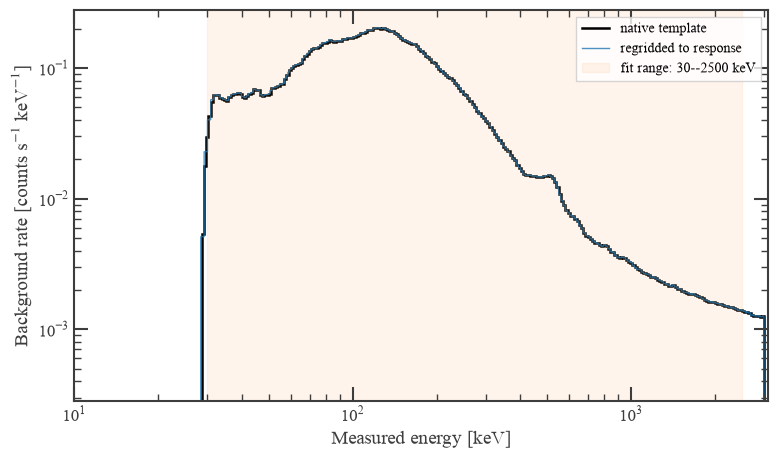

Template / regridded total rate [counts/s]: 41.58140702284204 41.58140702284204


In [8]:
from astropy.io import fits

with fits.open(background_template_path) as hdul:
    ebounds = hdul['EBOUNDS'].data
    template_edges = np.r_[ebounds['E_MIN'], ebounds['E_MAX'][-1]]
    template_rate = np.asarray(hdul['SPECTRUM'].data['RATE'], float)
    np.testing.assert_allclose(hdul['SPECTRUM'].data['COUNTS'],
                               template_rate*hdul['SPECTRUM'].header['EXPOSURE'])
    print('Template range [keV]:', template_edges[[0,-1]])
    print('Components:', hdul['COMPONENTS'].columns.names[1:])

background = get_bto_background(response, background_template=background_template_path)
background_path = output_path / 'bto1_background.bak'
write_ogip_background(background, response, background_path, exposure_s=40.0, overwrite=True)
emeas = np.sqrt(response.measured_energy_edges_keV[:-1]*response.measured_energy_edges_keV[1:])
fig, ax = plt.subplots(figsize=(8,4.8))
ax.stairs(template_rate/np.diff(template_edges), template_edges,
          color='black', lw=1.8, label='native template')
ax.stairs(background.rate_per_channel/np.diff(response.measured_energy_edges_keV),
          response.measured_energy_edges_keV, color='tab:blue', lw=1., alpha=0.8,
          label='regridded to response')
ax.axvspan(30.,2500., color='tab:orange', alpha=0.08, label='fit range: 30--2500 keV')
ax.set(xscale='log', yscale='log', xlim=(10.,3100.), xlabel='Measured energy [keV]',
       ylabel=r'Background rate [counts s$^{-1}$ keV$^{-1}$]')
ax.legend(frameon=True, fontsize=10)
style_axes(ax)
fig.tight_layout()
fig.savefig(output_path/'bto_background_quicklook.png', dpi=180)
plt.show()
print('Template / regridded total rate [counts/s]:', template_rate.sum(), background.rate_per_channel.sum())

#### 8. Define a Band spectrum and simulate a fake PHA

The callable passed to `simulate_bto_spectrum` is interpreted as differential
photon flux in ph cm$^{-2}$ s$^{-1}$ keV$^{-1}$ and is numerically integrated
inside every true-energy bin. For `astromodels.Band`, `xp` is the peak of
$E^2dN/dE$, while the branch energy is
$E_b=(\alpha-\beta)x_p/(2+\alpha)$. The returned fake-spectrum object keeps
source, background, total expectation, and the Poisson realization separately.

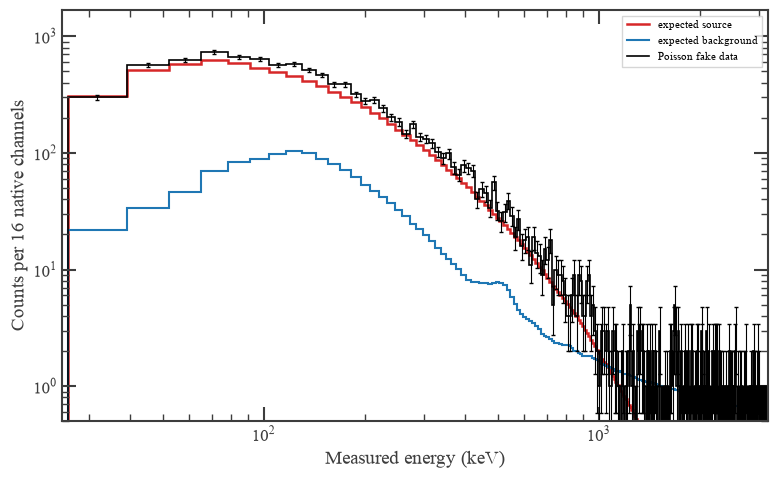

source/background/simulated totals: 8484.370385967875 1663.2562809136816 10192


In [9]:
band = Band()
band.beta.value = -3.0  # move inside the new bounds before changing them
band.beta.min_value, band.beta.max_value = -20.0, -2.01
band.K.value, band.alpha.value, band.xp.value, band.beta.value = 0.030210450807, -0.360, 472.34624, -11.921
band.piv.value = 500.0
pha_path = output_path / 'bto1_fake.pha'
fake = simulate_bto_spectrum(response, band, 40.0, background=background,
                             poisson=True, random_seed=36512, output_pha=pha_path, overwrite=True)
ql_group = 16
n_native = (len(fake.simulated_counts)//ql_group)*ql_group
ql_edges = response.measured_energy_edges_keV[:n_native+1:ql_group]
ql_source = fake.expected_source_counts[:n_native].reshape(-1, ql_group).sum(axis=1)
ql_background = fake.expected_background_counts[:n_native].reshape(-1, ql_group).sum(axis=1)
ql_observed = fake.simulated_counts[:n_native].reshape(-1, ql_group).sum(axis=1)
ql_centers = np.sqrt(np.clip(ql_edges[:-1],1e-6,None)*np.clip(ql_edges[1:],1e-6,None))
use = (ql_edges[:-1] >= 20.0) & (ql_edges[1:] <= 3200.0)
first, last = np.flatnonzero(use)[[0,-1]]
sl = slice(first,last+1); edge_slice = ql_edges[first:last+2]
fig, ax = plt.subplots(figsize=(8,5))
ax.stairs(ql_source[sl], edge_slice, lw=1.8, label='expected source', color='tab:red')
ax.stairs(ql_background[sl], edge_slice, lw=1.5, label='expected background', color='tab:blue')
ax.stairs(ql_observed[sl], edge_slice, lw=1.2, label='Poisson fake data', color='black')
ax.errorbar(ql_centers[sl], ql_observed[sl], yerr=np.sqrt(np.clip(ql_observed[sl],1.0,None)), fmt='none', color='black', elinewidth=0.8, capsize=1.5)
ax.set(xscale='log', yscale='log', xlim=(25,3200), ylim=(0.5,None), xlabel='Measured energy (keV)', ylabel=f'Counts per {ql_group} native channels')
style_axes(ax)
ax.legend(frameon=True); fig.tight_layout(); fig.savefig(output_path/'bto_fake_spectrum_quicklook.png', dpi=180); plt.show()
print('source/background/simulated totals:', fake.expected_source_counts.sum(), fake.expected_background_counts.sum(), fake.simulated_counts.sum())

#### 9. Load the products in threeML

The OGIP files are ordinary threeML inputs. CC remains the reference in a joint fit; an optional BTO effective-area correction can later be fixed with `fix_effective_area_correction(1.0)` or fitted with `use_effective_area_correction(0.5, 1.5)`.

In [10]:
bto_plugin = OGIPLike('bto1', observation=fake.pha_path, background=background.path,
                      response=str(response.rmf_path), arf_file=str(response.arf_path), verbose=False)
bto_plugin.set_active_measurements('30-2500')
bto_plugin.rebin_on_background(20)
print('active grouped bins:', len(bto_plugin.current_observed_counts))
print('public nuisance parameters:', list(bto_plugin.nuisance_parameters))

16:49:33 WARNING   Maximum MC energy (3000.0) is smaller than maximum EBOUNDS energy                ]8;id=6431732;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=6431733;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/OGIP/response.py#125\125]8;;\
                  (3242.5715539545627)                                                                             

WARNING   Minimum MC energy (15.0) is larger than minimum EBOUNDS energy (0.0)             ]8;id=6431741;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=6431742;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/utils/OGIP/response.py#133\133]8;;\

INFO      Auto-probed noise models:                                                    ]8;id=6431751;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=6431752;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

INFO      - observation: poisson                                                       ]8;id=6431760;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=6431761;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

INFO      - background: gaussian                                                       ]8;id=6431769;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=6431770;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

INFO      Range 30-2500 translates to channels 36-3139                                ]8;id=6431778;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=6431779;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

16:49:36 INFO      Now using 75 bins                                                           ]8;id=6431787;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=6431788;file:///opt/miniconda3/envs/cosipy/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1706\1706]8;;\

active grouped bins: 75
public nuisance parameters: ['cons_bto1']
